In [10]:
import numpy as np
import matplotlib.pyplot as plt
# import packages
from Equipments import BNC575, Weeder, SR400, MCBOX, Andor, Agilent, ThorlabsPM, LeCroyScope
from DataProcessing.Plot import PlotSaver

import pyvisa
import time


In [12]:
ps = PlotSaver("X:/migratedData/Rydberg_QIS/data")

In [2]:
rm = pyvisa.ResourceManager()
print(rm.list_resources())

('ASRL1::INSTR', 'ASRL2::INSTR', 'ASRL3::INSTR', 'ASRL4::INSTR', 'ASRL5::INSTR', 'ASRL6::INSTR', 'ASRL7::INSTR', 'GPIB0::3::INSTR', 'GPIB0::9::INSTR', 'TCPIP0::169.254.110.10::inst0::INSTR', 'USB1::0x1313::0x807B::241023118::0::INSTR')


In [3]:
lecroyscope = LeCroyScope.LeCroyScope('GPIB0::3::INSTR')

*IDN -> *IDN LECROY,9354AM,935403739,08.2.1



In [4]:
t,v,info = lecroyscope.read_waveform("C2")

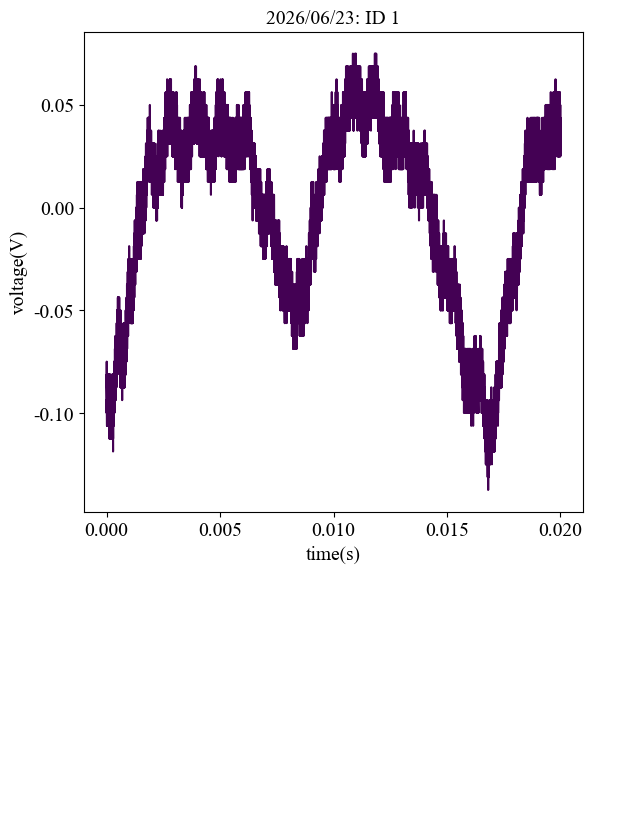

In [13]:
ps.Plot2D(x = t, y = None, Z = v,
          xlabel = "time(s)", zlabel = "voltage(V)")

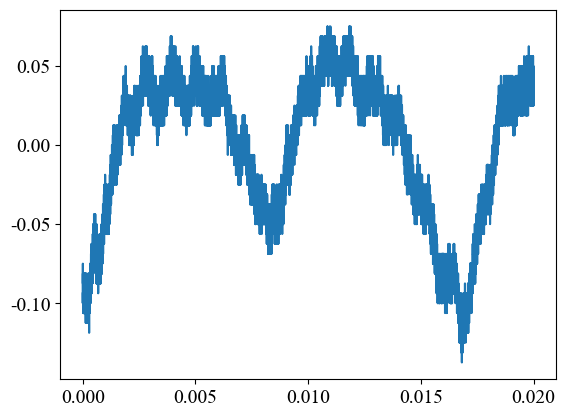

In [5]:
plt.plot(t,v)

In [7]:
rms = np.sqrt(np.mean(v**2))
print(rms)

0.04560522200241001


In [8]:
V = np.fft.rfft(v)
freq = np.fft.rfftfreq(len(t),d = 1/25e6)

C:\Users\raithel-lab\AppData\Local\miniconda3\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\raithel-lab\AppData\Local\miniconda3\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


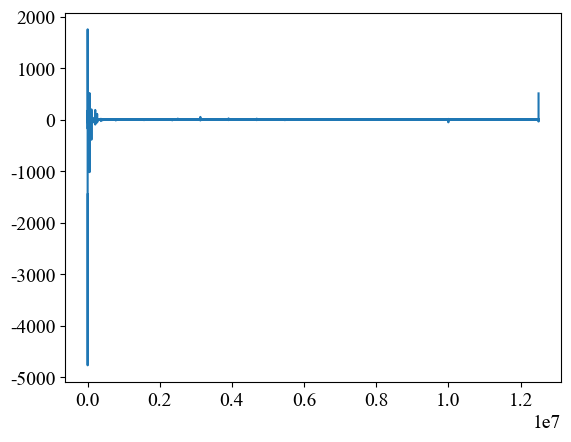

In [9]:
plt.plot(freq,V)